In [ ]:
import sys
sys.path.insert(0, '..')

In [ ]:
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Cargar datos

In [ ]:
clusters = pd.read_csv('./../data/processed/largest_clusters.csv')
members = pd.read_csv('./../data/processed/largest_clusters_members.csv')

Seleccionar datos del cúmulo.

In [ ]:
cluster_name = 'NGC_3201'
cluster = clusters[clusters['Name'] == cluster_name]
cluster_members = members[members['Name'] == cluster_name]

In [ ]:
ra0 = float(cluster['RA_ICRS'].values[0]) # grados
dec0 = float(cluster['DE_ICRS'].values[0]) # grados
d0 = float(cluster['dist50'].values[0])  # pc

In [ ]:
ras = cluster_members['RA_ICRS'].values # grados
decs = cluster_members['DE_ICRS'].values # grados
Ms = cluster_members['Mass50'].values  # M_sun
M_mean = np.mean(Ms)
M_tot = np.sum(Ms)

Realizar proyección gnomónica.

In [ ]:
X, Y = utils.tangent_plane_projection(ras, decs, ra0, dec0, d0)

Calcular radios supeficiales.

In [ ]:
Rs = np.sqrt(X**2 + Y**2)

## Ajuste del perfil de densidad superficial

Calcular la densidad de número superficial observada.

In [ ]:
def calculate_num_surface_density(Rs, num_bins=30):
    counts, bin_edges = np.histogram(Rs, bins=num_bins)
    areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

    Rs_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    Sigma_obs = counts / areas
    return Rs_mid, Sigma_obs

Definir número de bines.

In [ ]:
N = len(Rs)
num_bins = int(np.sqrt(N))

In [ ]:
Rs_mid, Sigma_obs = calculate_num_surface_density(Rs, num_bins)

Estimaciones iniciales.

In [ ]:
k_guess = np.max(Sigma_obs)
rc_guess = np.median(Rs) * 0.5
rt_guess = np.max(Rs)

Realizar ajuste.

In [ ]:
popt_2d, pcov_2d = curve_fit(
    utils.num_surface_density,
    Rs_mid, Sigma_obs,
    p0=[rc_guess, rt_guess, k_guess],
    bounds=(0, np.inf),
    maxfev=10000,
)

Valores obtenidos.

In [ ]:
rc_2d, rt_2d, k_2d = popt_2d
perr_2d = np.sqrt(np.diag(pcov_2d))

## Rejection Sampling

In [ ]:
Z = utils.rejection_sampling(Rs, rc_2d, rt_2d, k_2d, seed=23)

Seleccionar datos que no sean NaN.

In [ ]:
valid_mask = np.isfinite(Z)
X_v = X[valid_mask]
Y_v = Y[valid_mask]
Z_v = Z[valid_mask]
Ms_v = Ms[valid_mask]

## Dispersión de velocidades de Hernquist

Calcular el radio de mitad de masa.

In [ ]:
def half_mass_radius(x, y, z, masses):
    """
    Calcula el half-mass radius de un cúmulo.
    
    Parámetros:
        x, y, z : array — coordenadas de cada miembro
        masses  : array — masa de cada miembro
    
    Retorna:
        r_half  : float — half-mass radius
        com     : ndarray — centro de masa [x, y, z]
    """
    x, y, z, masses = map(np.asarray, [x, y, z, masses])
    
    # Centro de masa
    total_mass = masses.sum()
    com = np.array([
        (masses * x).sum(),
        (masses * y).sum(),
        (masses * z).sum(),
    ]) / total_mass
    
    # Distancia de cada miembro al centro de masa
    dx = x - com[0]
    dy = y - com[1]
    dz = z - com[2]
    radii = np.sqrt(dx**2 + dy**2 + dz**2)
    
    # Ordenar por distancia y acumular masa
    sort_idx = np.argsort(radii)
    cumulative_mass = np.cumsum(masses[sort_idx])
    
    # Encontrar el radio donde se acumula el 50% de la masa
    half_mass = total_mass / 2.0
    idx_half = np.searchsorted(cumulative_mass, half_mass)
    
    r_half = radii[sort_idx[idx_half]]
    
    return r_half, com

Radio de mitad de masa y centro de masa obtenidos.

In [ ]:
r_half, com = half_mass_radius(X_v, Y_v, Z_v, Ms_v)

### Longitud de escala $a$

La longitud de escala y el radio de mitad de masa se relaciona según Hernquist como: 

$$r_{1/2} = (1 + \sqrt{2})a$$

In [ ]:
a = r_half / (1 + np.sqrt(2))

Calcular radios en 3D.

In [ ]:
rs = np.sqrt(X_v**2 + Y_v**2 + Z_v**2)

Calcular dispersión de velocidades de Hernquist.

In [ ]:
def hernquist_sig2(r, M, a, G):
    """
    Dispersión de velocidades radiales isotrópica del perfil de Hernquist.

    Parámetros
    ----------
    r : array - Radio (mismas unidades que a)
    M : float - Masa total
    a : float - Longitud de escala
    G : float - Constante gravitacional

    Retorna
    -------
    v_r_sq : array - <v_r²> ≥ 0, ceros donde r == 0
    """
    r = np.asarray(r, dtype=float)

    v_r_sq = np.zeros_like(r)
    mask = r > 0  # evita log(0) y división por cero

    r_ = r[mask]
    s  = r_ / a  # variable adimensional, reduce repetición

    # term1: (12r(r+a)^3 / a^4) * ln((r+a)/r)
    # Reescrito en términos de s:
    # 12 * s * (1 + s)^3 * ln(1 + 1/s)
    term1 = 12.0 * s * (1.0 + s)**3 * np.log1p(1.0 / s)

    # term2: (r/(r+a)) * [25 + 52(r/a) + 42(r/a)^2 + 12(r/a)^3]
    # Reescrito en términos de s:
    # s/(1+s) * poly(s)
    poly  = 25.0 + 52.0 * s + 42.0 * s**2 + 12.0 * s**3
    term2 = (s / (1.0 + s)) * poly

    v_r_sq[mask] = (G * M / (12.0 * a)) * (term1 - term2)

    # Las dispersiones son mayores que cero
    v_r_sq = np.maximum(v_r_sq, 0.0)

    return v_r_sq

Dispersión de velocidades obtenida.

In [ ]:
sig2 = hernquist_sig2(rs, M_tot, a, 4.3e-3)

## Gráfica

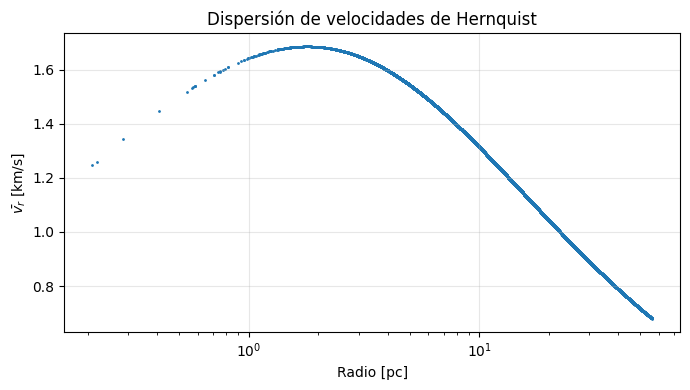

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(rs, np.sqrt(sig2), s=1)
ax.set_xlabel('Radio [pc]')
ax.set_ylabel(r'$\bar{v_r}  $ [km/s]')
ax.set_title('Dispersión de velocidades de Hernquist')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()